<a href="https://colab.research.google.com/github/ranjot-kaur123/CHAICODE-first/blob/main/Hve_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name:Ranjot Kaur    

Roll No:23111041

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os, pandas as pd, numpy as np

zip_path = '/content/drive/MyDrive/fault/HVE_Faults.zip'
extract_path = '/content/data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

data, labels = [], []

base_path = '/content/data/10-04-25_expriment'

for fault_type in os.listdir(base_path):
    fault_path = os.path.join(base_path, fault_type)

    if os.path.isdir(fault_path):
        for file in os.listdir(fault_path):
            if file.lower().endswith('.csv'):

                file_path = os.path.join(fault_path, file)

                try:
                    df = pd.read_csv(file_path, skiprows=2, header=None)
                    df = df.apply(pd.to_numeric, errors='coerce').dropna()

                    signal = df.iloc[:, 1].values

                    if len(signal) > 500:
                        data.append(signal)
                        labels.append(fault_type)
                except:
                    continue

print("Samples:", len(data))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Samples: 165


In [ ]:
from collections import Counter
from sklearn.utils import resample

print("Before:", Counter(labels))

data_balanced, labels_balanced = [], []
max_count = max(Counter(labels).values())

for label in set(labels):
    class_data = [d for d, l in zip(data, labels) if l == label]

    resampled = resample(class_data,
                         replace=True,
                         n_samples=max_count,
                         random_state=42)

    data_balanced.extend(resampled)
    labels_balanced.extend([label]*len(resampled))

data, labels = data_balanced, labels_balanced

print("After:", Counter(labels))

Before: Counter({'Point-cylindrical(bottom)_7.4kv_2cm_80v': 77, 'cylindrical-Hemispherical(bottom)_12.2kv_1.5cm_110v': 52, 'cylindrical-cylindrical_11.2kv_1.5cm': 15, 'point-point_2.5cmgap_9.5kv_99vpks_440mvpkpd(6-5-25)(20mv,20v yaxis(PD,s)': 11, 'Point-Hemispherical_6.5kv_1.5cm_66.7v': 5, 'Hemispherical-Hemispherical_12.8kv_1.5cm_137v': 5})
After: Counter({'Hemispherical-Hemispherical_12.8kv_1.5cm_137v': 77, 'cylindrical-cylindrical_11.2kv_1.5cm': 77, 'point-point_2.5cmgap_9.5kv_99vpks_440mvpkpd(6-5-25)(20mv,20v yaxis(PD,s)': 77, 'Point-Hemispherical_6.5kv_1.5cm_66.7v': 77, 'Point-cylindrical(bottom)_7.4kv_2cm_80v': 77, 'cylindrical-Hemispherical(bottom)_12.2kv_1.5cm_110v': 77})


In [ ]:
def process_signal(signal):

    signal = np.diff(signal)
    signal = (signal - np.mean(signal)) / (np.std(signal) + 1e-6)

    signal = np.resize(signal, 1000)

    return signal

In [ ]:
X = np.array([process_signal(sig) for sig in data])
X = X[..., np.newaxis]

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(labels)

print("Shape:", X.shape)

Shape: (462, 1000, 1)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([

    # CNN Feature Extraction
    layers.Conv1D(32, 3, activation='relu', input_shape=(1000,1)),
    layers.MaxPooling1D(2),

    layers.Conv1D(64, 3, activation='relu'),
    layers.MaxPooling1D(2),

    # LSTM Sequence Learning
    layers.LSTM(64, return_sequences=False),

    # Dense Layer
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    # Output Layer
    layers.Dense(6, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 998, 32)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 499, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 497, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 248, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,454 (189.27 KB)

 Trainable params: 48,454 (189.27 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=16,
    validation_data=(X_test, y_test)
)

Epoch 1/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 150ms/step - accuracy: 0.3252 - loss: 1.7263 - val_accuracy: 0.3871 - val_loss: 1.5143
Epoch 2/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 8s 296ms/step - accuracy: 0.4661 - loss: 1.3015 - val_accuracy: 0.3333 - val_loss: 1.3553
Epoch 3/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 258ms/step - accuracy: 0.5583 - loss: 1.0485 - val_accuracy: 0.7097 - val_loss: 0.7784
Epoch 4/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 136ms/step - accuracy: 0.6802 - loss: 0.7584 - val_accuracy: 0.5484 - val_loss: 0.9525
Epoch 5/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 181ms/step - accuracy: 0.6775 - loss: 0.7516 - val_accuracy: 0.8065 - val_loss: 0.5816
Epoch 6/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - accuracy: 0.7290 - loss: 0.6411 - val_accuracy: 0.7634 - val_loss: 0.5258
Epoch 7/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 146ms/step - accuracy: 0.7425 - loss: 0.5920 - val_accuracy: 0.7957 - val_loss: 0.4746
Epoch 8/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 213ms/step - accuracy: 0.7154 - loss: 0.6052 - val_accuracy: 0.

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 162ms/step
Accuracy: 0.978494623655914


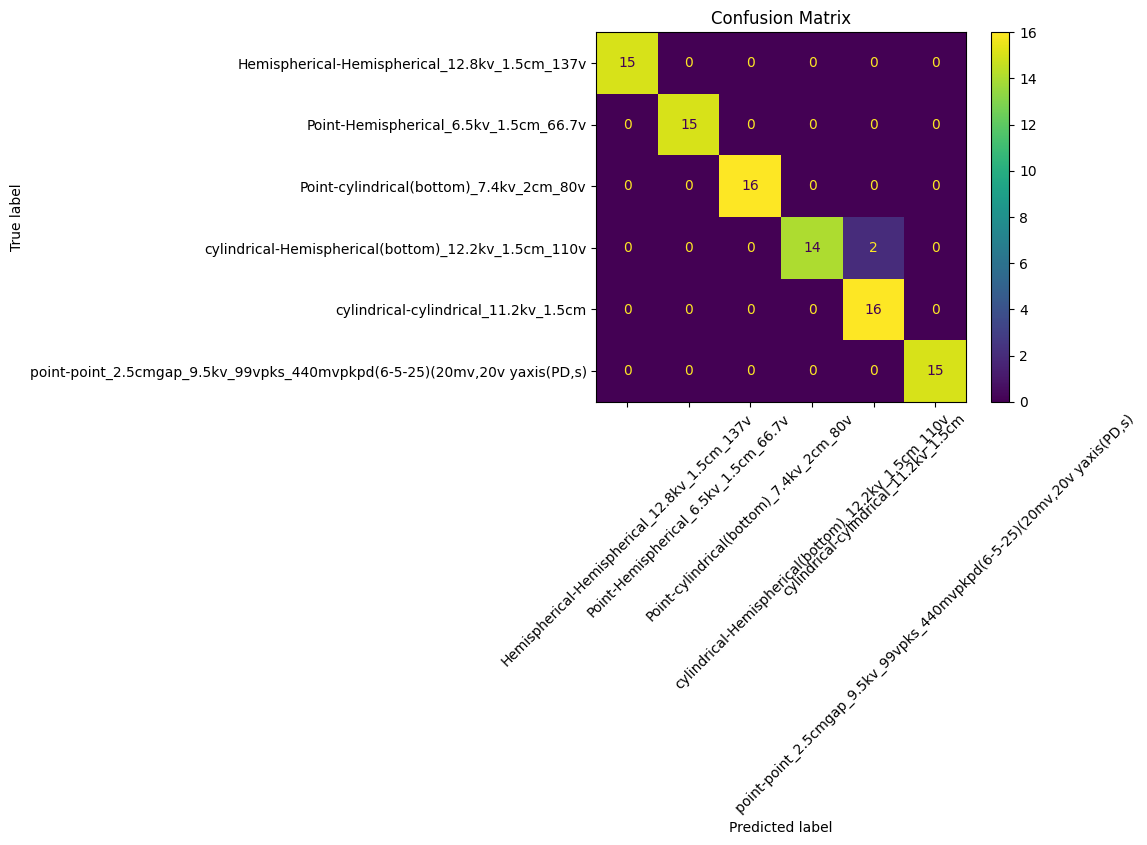

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred_classes))

cm = confusion_matrix(y_test, y_pred_classes)

disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()